<h1>Успеваемость студентов</h1>

## Подключение необходимых библиотек и функций

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering, SpectralClustering

import warnings
warnings.filterwarnings('ignore')


## Обзор датасета и загрузка данных

In [ ]:
df = pd.read_csv('student_performance_updated_1000.csv' )
# Первичный осмотр
print("Первые 5 строк")
display(df.head())

print("\nИнформация о датасете")
df.info()

print("\nСтатистическое описание")
display(df.describe())


=== Первые 5 строк ===


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True



=== Информация о датасете ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB

=== Статистическое описан

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,960.000000,960.000000,950.000000,967.000000,957.000000,960.000000,976.000000,959.000000
mean,5416.019792,85.510417,17.630526,77.598759,1.520376,80.030208,2.406967,77.248175
std,2653.748319,7.332125,6.272132,10.006640,1.046439,9.493652,1.620267,19.298148
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,3113.500000,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,63.000000
50%,5396.500000,88.000000,18.000000,78.000000,1.000000,80.000000,2.500000,76.000000
75%,7754.750000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


In [ ]:
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


## Описание набора данных

#### StudentID - Уникальный идентификатор студента
#### Name - Имя студента
#### Gender - Пол студента (Male/Female)
#### AttendanceRate - Процент посещаемости занятий
#### StudyHoursPerWeek - Количество часов учебы в неделю
#### PreviousGrade - Предыдущая оценка студента
#### ExtracurricularActivities - Количество внеклассных мероприятий
#### ParentalSupport - Уровень поддержки родителей (Low/Medium/High)
#### FinalGrade - Итоговая оценка (целевая переменная)
#### Study Hours - Часы самостоятельной учебы
#### Attendance (%) - Процент посещаемости (альтернативный показатель)
#### Online Classes Taken - Участие в онлайн-курсах (True/False)

## Распределение категориальных признаков

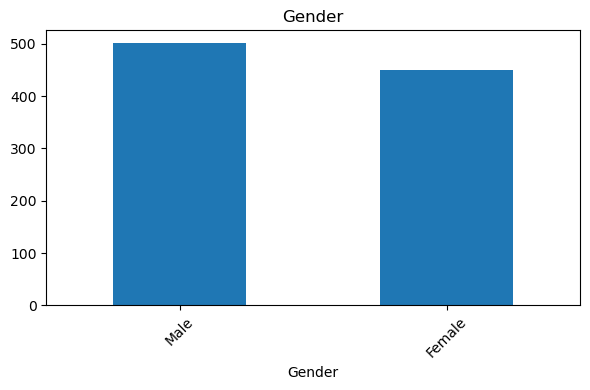

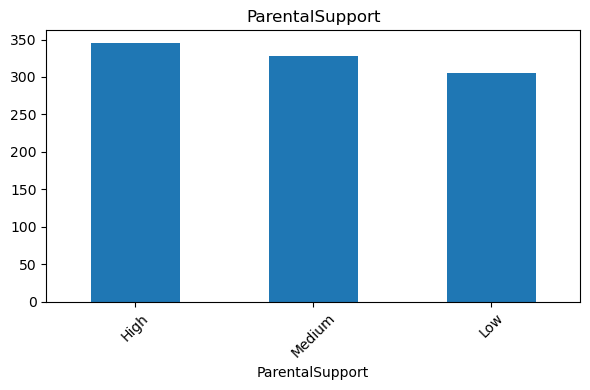

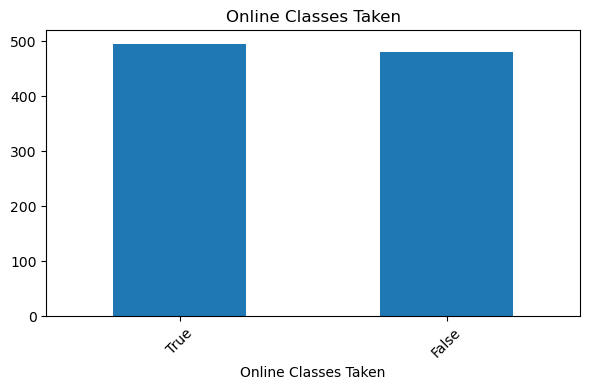

In [ ]:
cat_features = ['Gender', 'ParentalSupport', 'Online Classes Taken']

for col in cat_features:
    plt.figure(figsize=(6, 4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'{col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Распределение числовых признаков

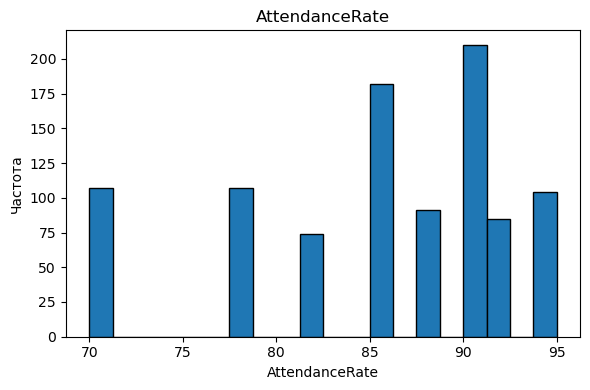

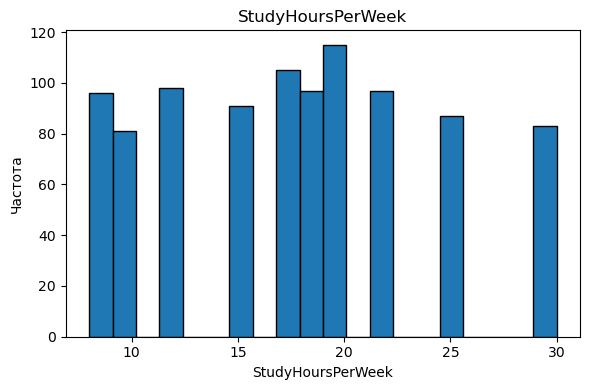

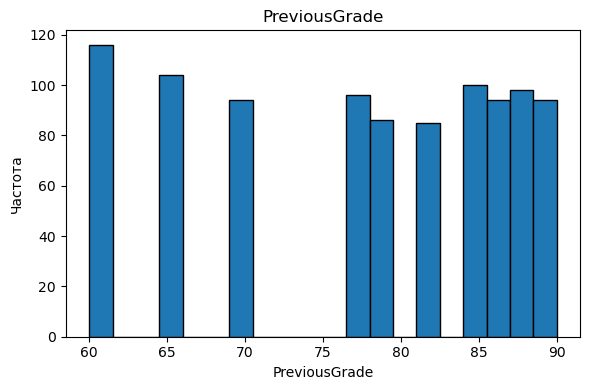

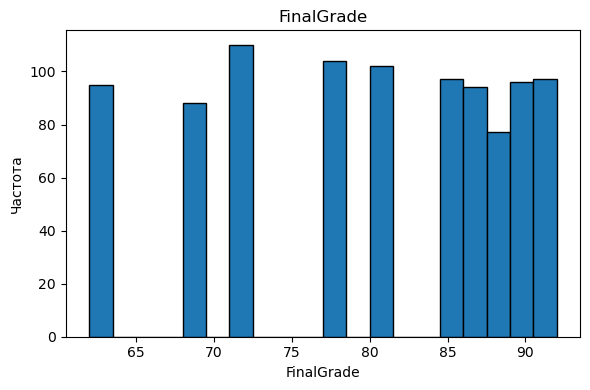

In [ ]:
num_features = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'FinalGrade']

for col in num_features:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=20, edgecolor='black')
    plt.title(f'{col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.tight_layout()
    plt.show()

## Матрица Кореляций

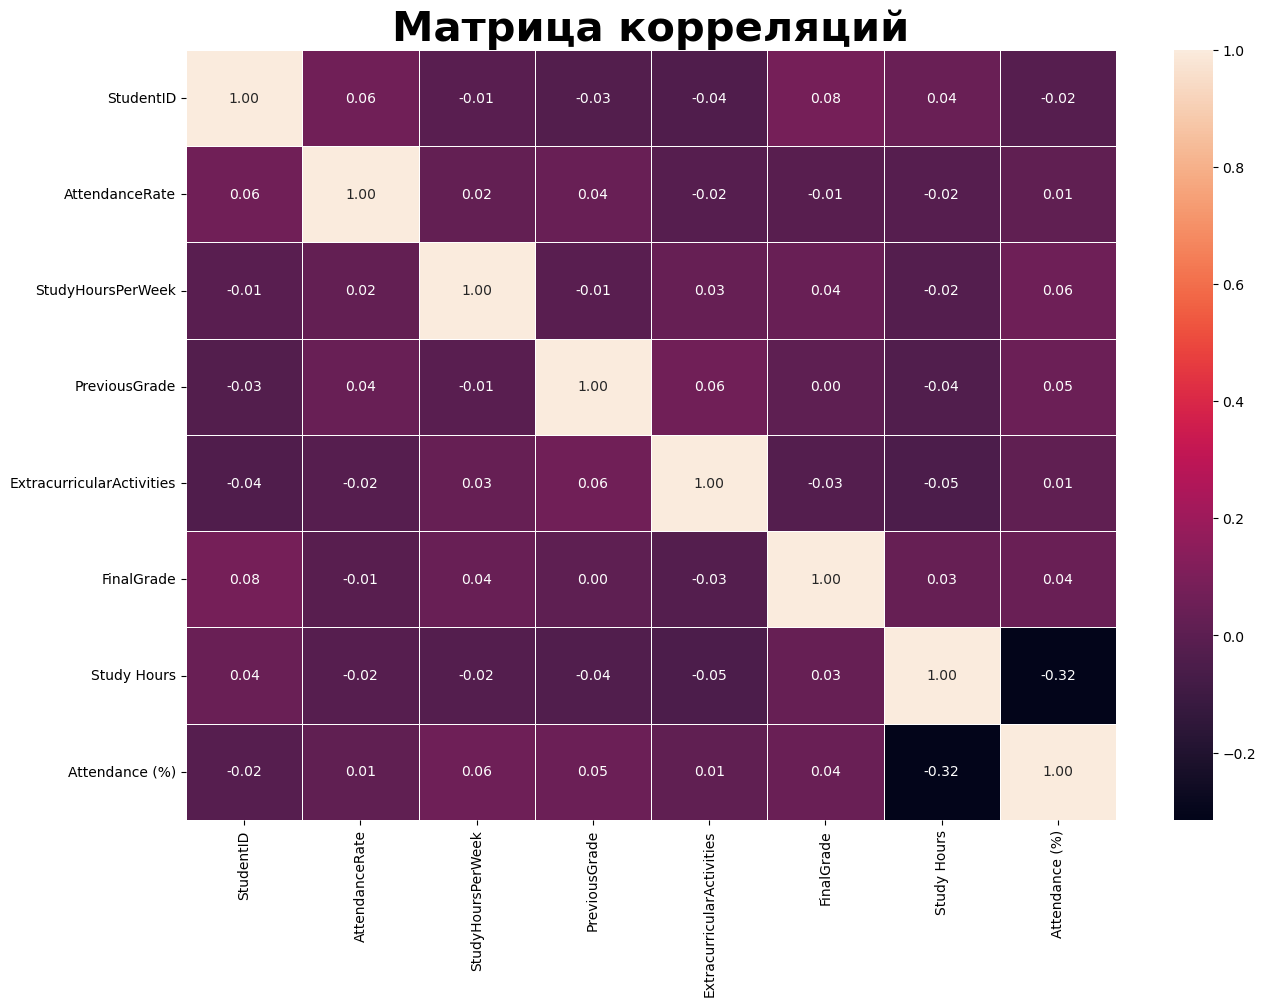

In [ ]:
corr = df.corr(numeric_only=True)

fig = plt.subplots(figsize=(15, 10))
sns.heatmap(corr, 
            annot=True, 
            fmt='.2f',
            linewidths=0.5)

plt.title('Матрица корреляций', fontsize=30, fontweight='bold')
plt.show()


<h1>Кластеризация</h1>

### Нормализация

In [ ]:
X = df.iloc[:, 2:]
Xcol = X.columns

In [ ]:
X

,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True
...,...,...,...,...,...,...,...,...,...,...
995,Male,85.0,20.0,NaN,1.0,High,72.0,0.8,80.0,True
996,Female,91.0,NaN,86.0,0.0,High,90.0,3.9,80.0,True
997,Male,85.0,8.0,82.0,2.0,Low,68.0,0.4,54.0,False
998,Male,88.0,17.0,60.0,2.0,High,85.0,0.9,53.0,True


In [ ]:
for col in X.select_dtypes(include=[np.number]).columns:
    X[col].fillna(X[col].median(), inplace=True)
for col in X.select_dtypes(include=['object']).columns:
    X[col].fillna(X[col].mode()[0], inplace=True)

In [ ]:
X = X.drop(['Attendance (%)', 'Study Hours'], axis=1, errors='ignore')
gender_map = {'Female':0, 'Male':1}
X['Gender'] = X['Gender'].map(gender_map)
parentalsupport_map = {'Low': 0, 'Medium': 1, 'High': 2}
X['ParentalSupport'] = X['ParentalSupport'].map(parentalsupport_map)
X['Online Classes Taken'] = X['Online Classes Taken'].astype(int)

In [ ]:
mms = MinMaxScaler()
X=pd.DataFrame(mms.fit_transform(X), columns=X.columns)

In [ ]:
X

,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Online Classes Taken
0,1.0,0.60,0.318182,0.600000,0.333333,1.0,0.600000,0.0
1,0.0,0.80,0.545455,0.833333,0.666667,0.5,0.833333,1.0
2,1.0,0.32,0.090909,0.166667,0.000000,0.0,0.200000,0.0
3,1.0,0.88,0.772727,1.000000,1.000000,1.0,1.000000,0.0
4,0.0,0.72,0.454545,0.733333,0.666667,0.5,0.766667,1.0
...,...,...,...,...,...,...,...,...
995,1.0,0.60,0.545455,0.600000,0.333333,1.0,0.333333,1.0
996,0.0,0.84,0.454545,0.866667,0.000000,1.0,0.933333,1.0
997,1.0,0.60,0.000000,0.733333,0.666667,0.0,0.200000,0.0
998,1.0,0.72,0.409091,0.000000,0.666667,1.0,0.766667,1.0


### Метод главных компонент

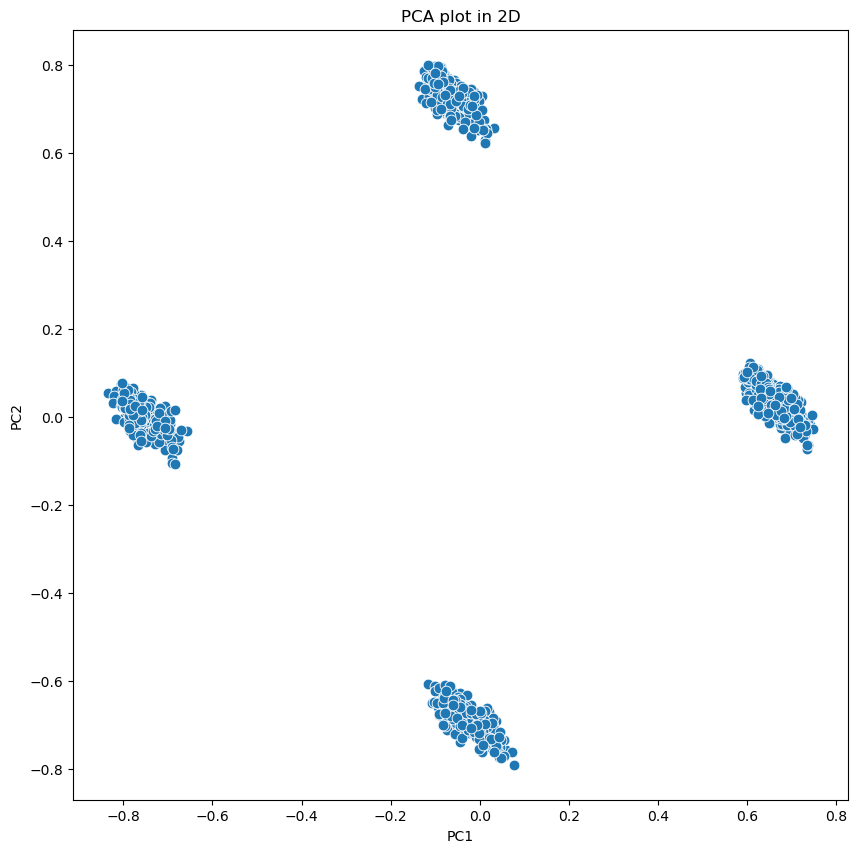

In [ ]:
principal_df = pd.DataFrame(data = PCA(n_components=2).fit_transform(X))
    
fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                s=60)

plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');

In [ ]:
def TSNEplot(pred=None):    
    tsne = TSNE(random_state=1)

    X_tsne = tsne.fit_transform(X)

    plt.figure(figsize=(12, 10))
    plt.scatter(X_tsne[:, 0], 
                X_tsne[:, 1], 
                c = pred, 
                edgecolor="none", 
                alpha=0.7, s=40,
        cmap=plt.cm.get_cmap("flare", 4))

    plt.colorbar()
    plt.title("t-SNE projection");

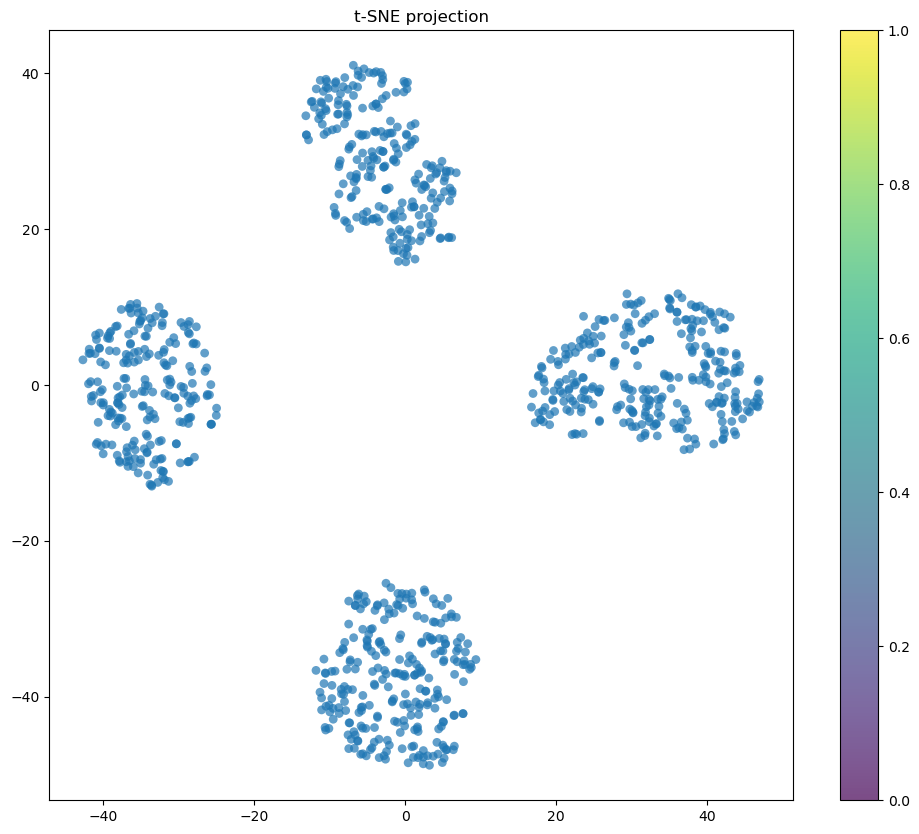

In [ ]:
TSNEplot()

In [ ]:
def PCAplot3D(x_data, y_data=None):
    components = PCA(n_components=3).fit_transform(x_data)

    fig = px.scatter_3d(
        components, 
        x=0, y=1, z=2, 
        color=y_data, 
        size=0.1*np.ones(len(X)), 
        opacity = 1,
        title='PCA plot in 3D',
        labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3'},
        width=900, height=900
    )
    fig.show()

In [ ]:
PCAplot3D(X)

### Кластеризация

### K-Means

In [ ]:
pca = PCA(n_components=2)

kmeans = KMeans(n_clusters=4, random_state=1, n_init='auto').fit(X)
centroids_pca = pca.fit_transform(kmeans.cluster_centers_)
pred_k = kmeans.labels_

principal_df = pd.DataFrame(data = PCA(n_components=2).fit_transform(X))

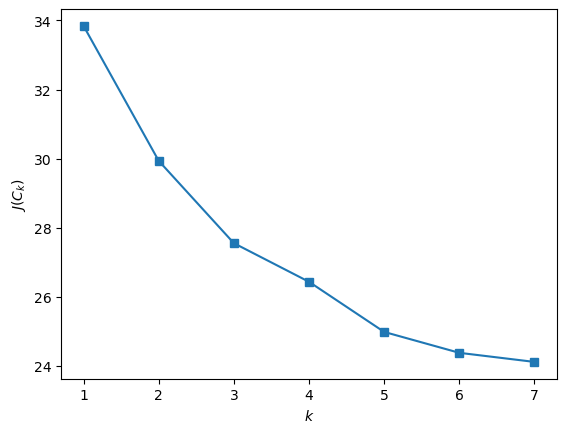

In [ ]:
inertia = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=1, n_init='auto').fit(X)
    inertia.append(np.sqrt(kmeans.inertia_))
    
plt.plot(range(1, 8), inertia, marker="s")
plt.xlabel("$k$")
plt.ylabel("$J(C_k)$");

In [ ]:
pca = PCA(n_components=2)


kmeans = KMeans(n_clusters=4, random_state=1, n_init='auto').fit(X)
centroids_pca = pca.fit_transform(kmeans.cluster_centers_)
pred_k = kmeans.labels_

principal_df = pd.DataFrame(data = PCA(n_components=2).fit_transform(X))

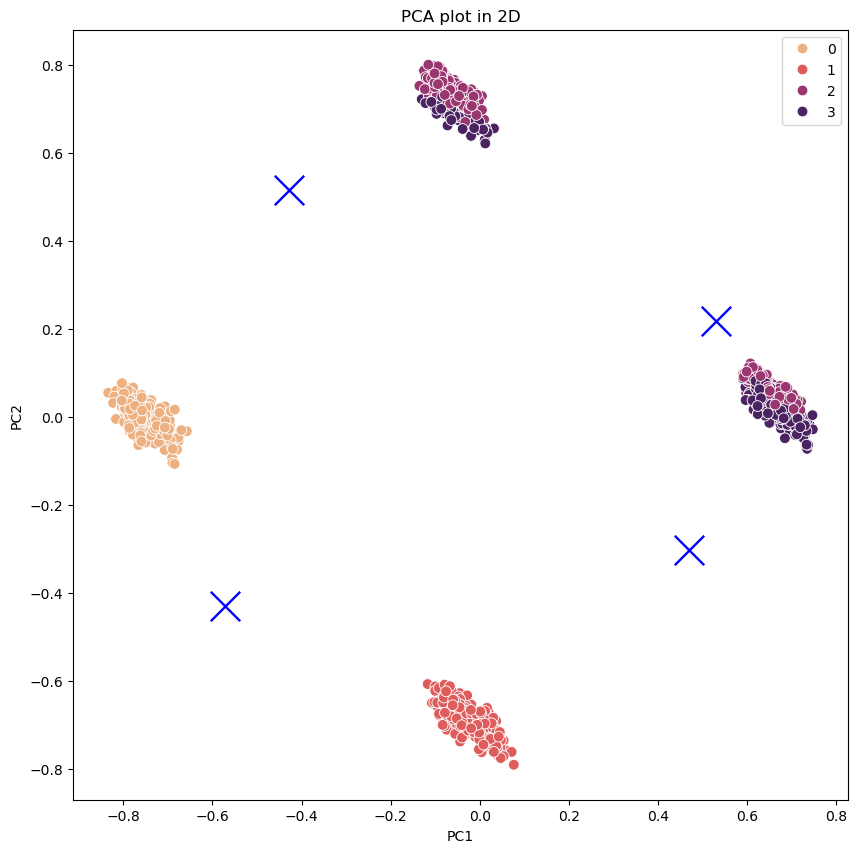

In [ ]:
fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = pred_k, 
                palette="flare", 
                s=60)
sns.scatterplot(x = centroids_pca[:,0], 
                y =  centroids_pca[:,1],  
                marker="x", 
                s=450, 
                color = 'blue')
plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');

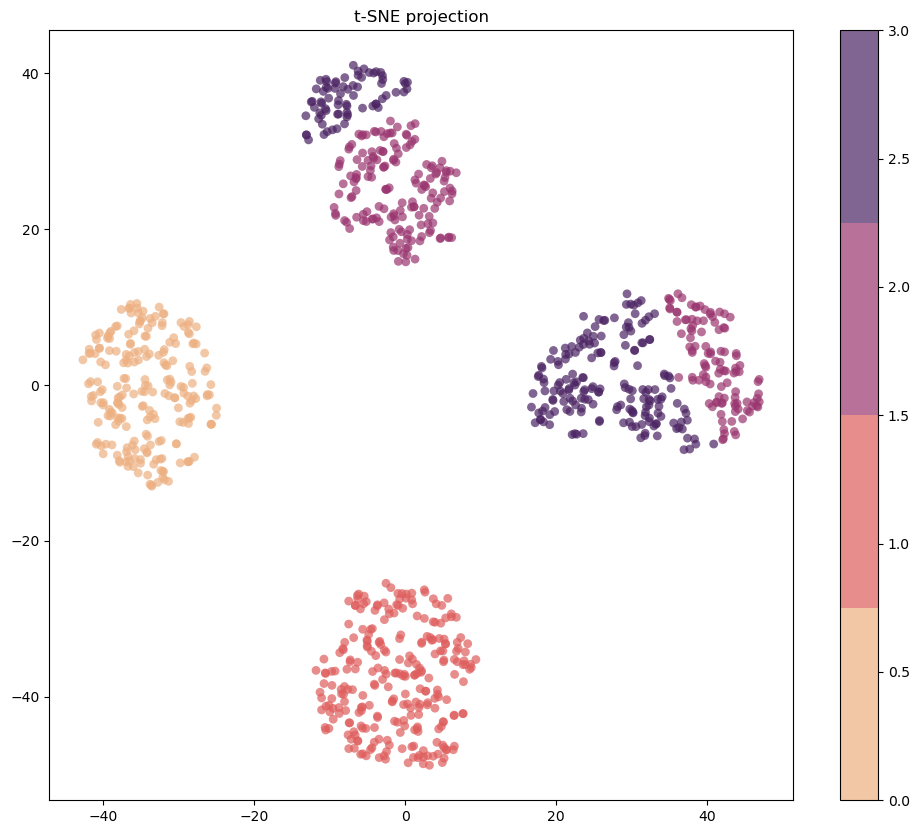

In [ ]:
TSNEplot(pred_k)

In [ ]:
PCAplot3D(X, pred_k)

### Agglomerative Clustering by Ward

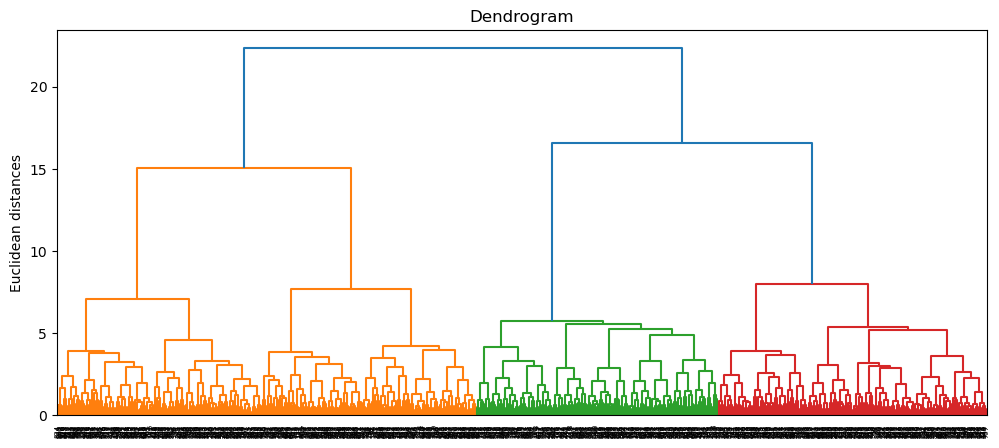

In [ ]:
import scipy.cluster.hierarchy as sch
from matplotlib import pyplot
pyplot.figure(figsize=(12, 5))
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.title('Dendrogram')
plt.ylabel('Euclidean distances')
plt.show()

In [ ]:
clustering_ward = AgglomerativeClustering(4).fit(X)
pred_ward = clustering_ward.labels_

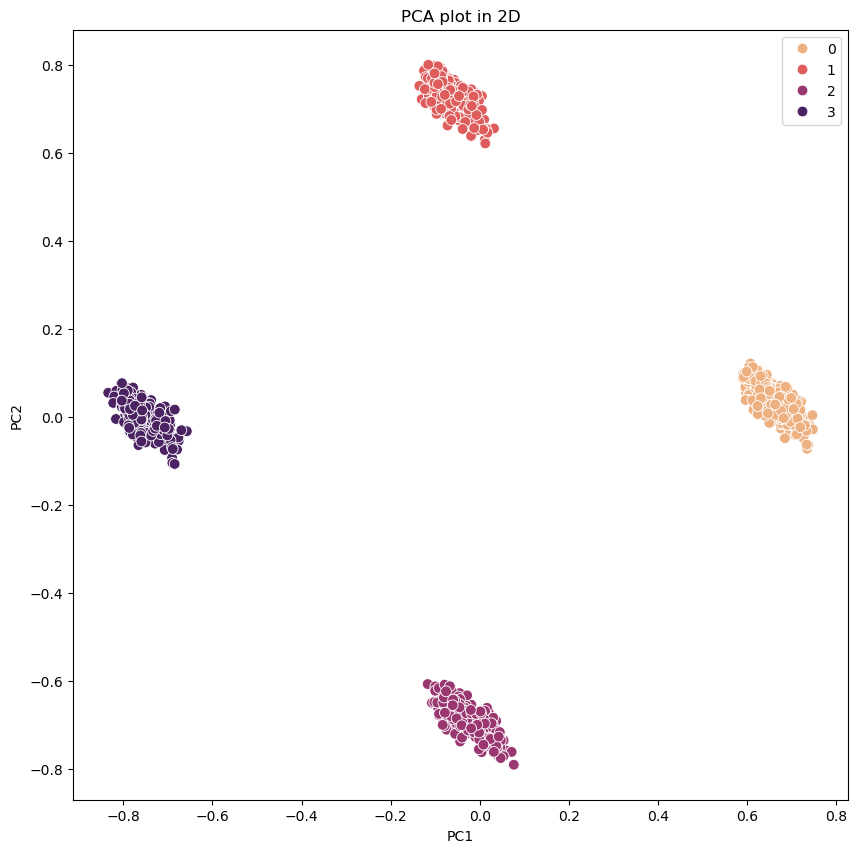

In [ ]:
fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = pred_ward, 
                palette="flare", 
                s=60)
plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');

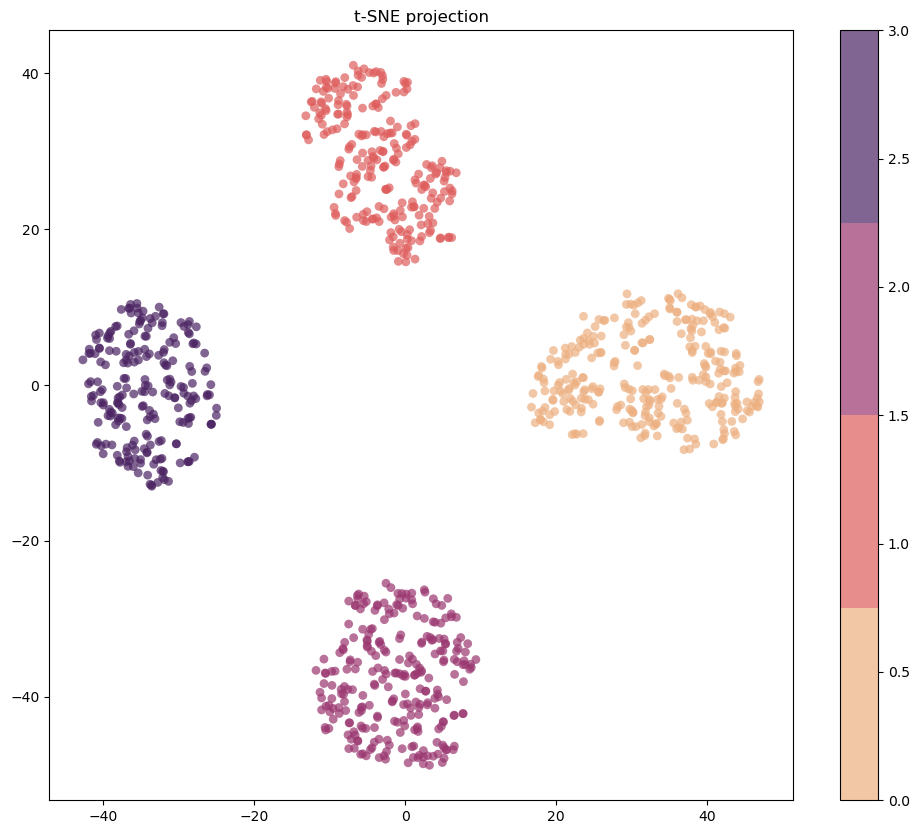

In [ ]:
TSNEplot(pred_ward)

In [ ]:
PCAplot3D(X, pred_ward)

### Spectral Clustering

In [ ]:
clustering_sp = SpectralClustering(4).fit(X)
pred_sp = clustering_sp.labels_

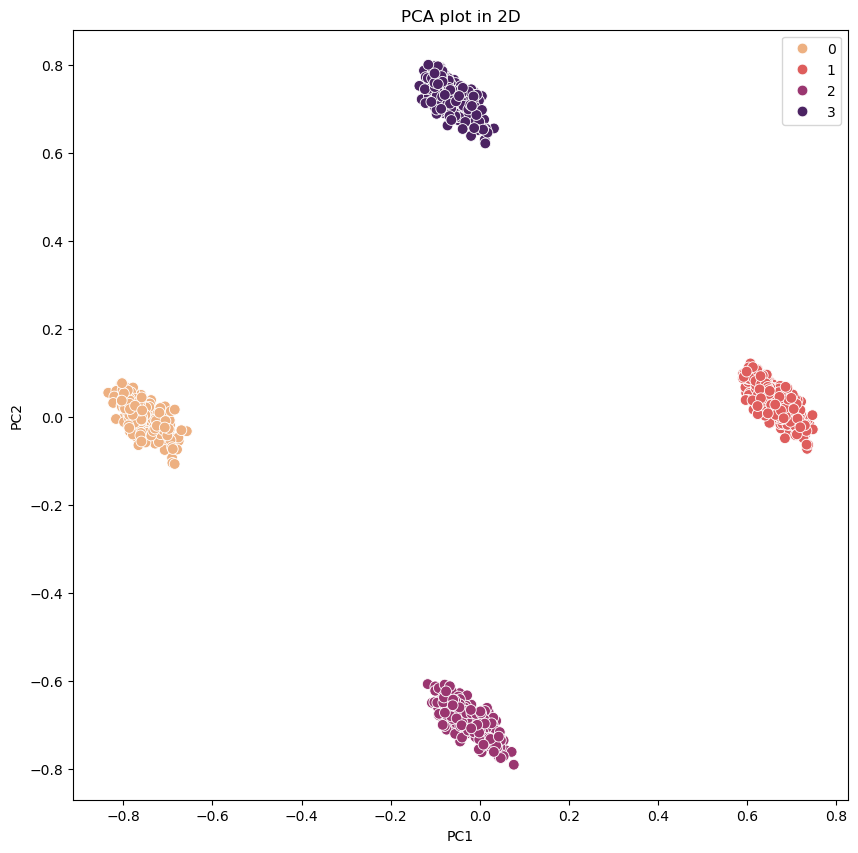

In [ ]:
fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = pred_sp, 
                palette="flare", 
                s=60)
plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');

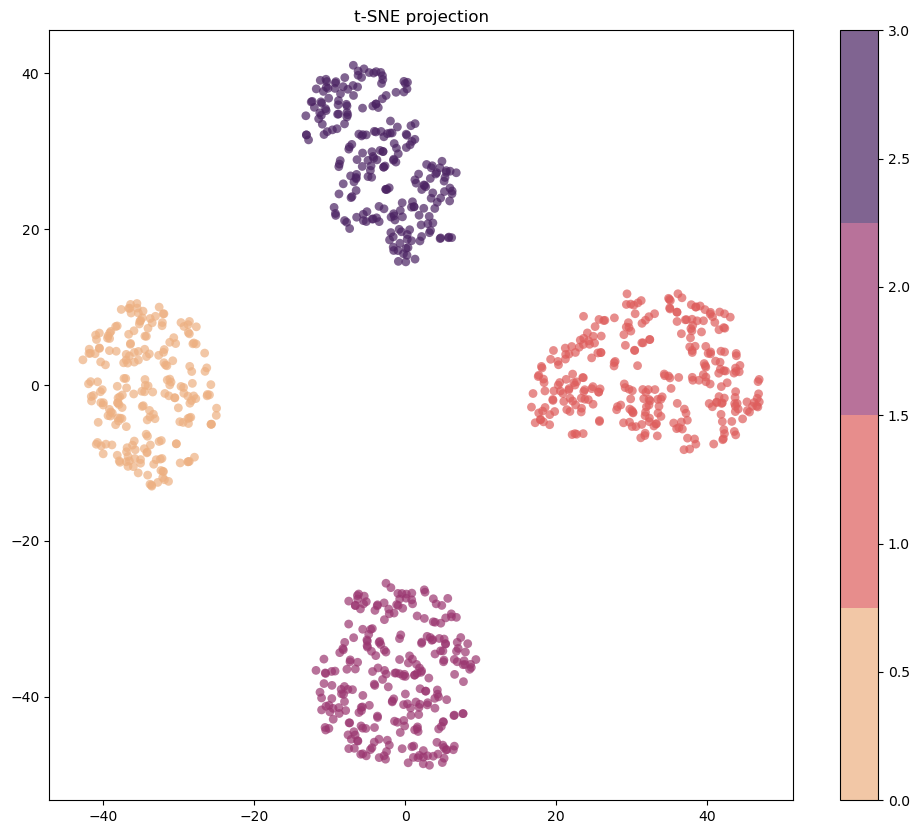

In [ ]:
TSNEplot(pred_sp)

In [ ]:
PCAplot3D(X, pred_sp)

In [ ]:
X['Cluster'] = pred_sp

In [ ]:
y = X['Cluster']
del X['Cluster']

In [ ]:
X

,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Online Classes Taken
0,1.0,0.60,0.318182,0.600000,0.333333,1.0,0.600000,0.0
1,0.0,0.80,0.545455,0.833333,0.666667,0.5,0.833333,1.0
2,1.0,0.32,0.090909,0.166667,0.000000,0.0,0.200000,0.0
3,1.0,0.88,0.772727,1.000000,1.000000,1.0,1.000000,0.0
4,0.0,0.72,0.454545,0.733333,0.666667,0.5,0.766667,1.0
...,...,...,...,...,...,...,...,...
995,1.0,0.60,0.545455,0.600000,0.333333,1.0,0.333333,1.0
996,0.0,0.84,0.454545,0.866667,0.000000,1.0,0.933333,1.0
997,1.0,0.60,0.000000,0.733333,0.666667,0.0,0.200000,0.0
998,1.0,0.72,0.409091,0.000000,0.666667,1.0,0.766667,1.0
